In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

# New Data Update
I have not pulled the high school enrollment variables alone (that’s from another database). Instead, the total school enrollment values can be used as the denominator for all rates and opportunity estimates for now. This does include all states’ data and not just Oregon. But you could start with just that if that will be helpful. I will add the high school enrollment values on Monday first thing. It would only matter for those schools that are K-12 schools for which we should use the high school enrollment values alone to calculate the AP rates as well as AP risk ratios (i.e., opportunity estimates such as APLIKELIHOOD_BL, APLIKELIHOOD_HI, and APLIKELIHOOD_AS values)

In [ ]:
#dummy = pd.read_csv("data\dummy.csv")
#dummy.head()

data = pd.read_csv("advanceddata_poc_v1.csv", low_memory = False)
data.head()

,COMBOKEY,LEA_STATE,LEAID,LEA_NAME,SCH_NAME,YEAR,SCH_APENR_IND,SCH_APCOURSES,ENR_AP,ENR_AP_AS,...,ENR,ENR_AS,ENR_BL,ENR_HI,ENR_WH,ENR_OTH,ENR_TEACH,APLIKELIHOOD_BL,APLIKELIHOOD_HI,APLIKELIHOOD_AS
0,10000201705,AL,100002,ALABAMA YOUTH SERVICES,WALLACE SCH - MT MEIGS CAMPUS,2011,NaN,NaN,NaN,NaN,...,382.0,0.0,236.0,8.0,131.0,7.0,NaN,NaN,NaN,NaN
1,10000201705,AL,100002,ALABAMA YOUTH SERVICES,WALLACE SCH - MT MEIGS CAMPUS,2013,NaN,NaN,NaN,NaN,...,1798.0,0.0,1001.0,0.0,797.0,0.0,62.000000,NaN,NaN,NaN
2,10000201705,AL,100002,Alabama Youth Services,Wallace Sch - Mt Meigs Campus,2017,NaN,NaN,NaN,NaN,...,133.0,0.0,72.0,5.0,54.0,2.0,5.320000,NaN,NaN,NaN
3,10000201705,AL,100002,Alabama Youth Services,Wallace Sch - Mt Meigs Campus,2020,NaN,NaN,NaN,NaN,...,110.0,0.0,63.0,1.0,46.0,0.0,4.583333,NaN,NaN,NaN
4,10000201706,AL,100002,ALABAMA YOUTH SERVICES,MCNEEL SCH - VACCA CAMPUS,2011,NaN,NaN,NaN,NaN,...,185.0,0.0,122.0,2.0,59.0,2.0,NaN,NaN,NaN,NaN


In [3]:
dist_data  = pd.read_csv("ap_equity_districts.csv", low_memory = False)

In [4]:
dist_data.head()

,Unnamed: 0,COMBOKEY,LEA_STATE,LEAID,LEA_NAME,SCH_NAME,YEAR,SCH_APENR_IND,SCH_APCOURSES,ENR_AP,...,PCT_ENR_AP_BL,PCT_ENR_AP_AS,PCT_ENR_AP_HI,PCT_ENR_AP_OTH,ENR_AP_GAP_BL,ENR_AP_GAP_AS,ENR_AP_GAP_HI,GEOG,SCHOOLS,MEAN_TYPE
0,1,NaN,AL,100002,ALABAMA YOUTH SERVICES,NaN,2011,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DISTRICT,8,overall
1,2,NaN,AL,100002,ALABAMA YOUTH SERVICES,NaN,2013,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DISTRICT,8,overall
2,3,NaN,AL,100002,ALABAMA YOUTH SERVICES,NaN,2017,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DISTRICT,8,overall
3,4,NaN,AL,100002,ALABAMA YOUTH SERVICES,NaN,2020,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DISTRICT,8,overall
4,5,NaN,AL,100005,ALBERTVILLE CITY,NaN,2011,0,0,182,...,0.0,0.0,0.018433,0.0,0.0,0.0,0.510204,DISTRICT,13,overall


In [88]:
dist_data['ENR'].iloc[0]

np.int64(2268)

In [8]:
dist_data_overall = dist_data[dist_data['MEAN_TYPE'] == 'overall']
dist_data_overall.head()

,Unnamed: 0,COMBOKEY,LEA_STATE,LEAID,LEA_NAME,SCH_NAME,YEAR,SCH_APENR_IND,SCH_APCOURSES,ENR_AP,...,PCT_ENR_AP_BL,PCT_ENR_AP_AS,PCT_ENR_AP_HI,PCT_ENR_AP_OTH,ENR_AP_GAP_BL,ENR_AP_GAP_AS,ENR_AP_GAP_HI,GEOG,SCHOOLS,MEAN_TYPE
0,1,NaN,AL,100002,ALABAMA YOUTH SERVICES,NaN,2011,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DISTRICT,8,overall
1,2,NaN,AL,100002,ALABAMA YOUTH SERVICES,NaN,2013,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DISTRICT,8,overall
2,3,NaN,AL,100002,ALABAMA YOUTH SERVICES,NaN,2017,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DISTRICT,8,overall
3,4,NaN,AL,100002,ALABAMA YOUTH SERVICES,NaN,2020,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DISTRICT,8,overall
4,5,NaN,AL,100005,ALBERTVILLE CITY,NaN,2011,0,0,182,...,0.0,0.0,0.018433,0.0,0.0,0.0,0.510204,DISTRICT,13,overall


In [50]:
type(dist_data_overall['LEAID'][0])

numpy.int64

In [ ]:
data.columns

Index(['COMBOKEY', 'LEA_STATE', 'LEAID', 'LEA_NAME', 'SCH_NAME', 'YEAR',
       'SCH_APENR_IND', 'SCH_APCOURSES', 'ENR_AP', 'ENR_AP_AS', 'ENR_AP_BL',
       'ENR_AP_HI', 'ENR_AP_WH', 'ENR_AP_OTH', 'SCH_FTETEACH_TOT', 'ENR',
       'ENR_AS', 'ENR_BL', 'ENR_HI', 'ENR_WH', 'ENR_OTH', 'ENR_TEACH',
       'APLIKELIHOOD_BL', 'APLIKELIHOOD_HI', 'APLIKELIHOOD_AS'],
      dtype='object')

In [19]:
districts_data = pd.read_csv("ap_equity_districts.csv", low_memory = False)
districts_data_or = districts_data[districts_data['LEA_STATE'] == "OR"]

In [51]:
districts_or = [int(x) for x in districts_data_or['LEAID'].unique()]



In [52]:
districts_or

[4100003,
 4100009,
 4100014,
 4100015,
 4100016,
 4100019,
 4100020,
 4100021,
 4100023,
 4100033,
 4100036,
 4100040,
 4100043,
 4100047,
 4100048,
 4100640,
 4101020,
 4101120,
 4101200,
 4101230,
 4101470,
 4101560,
 4101620,
 4101660,
 4101710,
 4101740,
 4101800,
 4101830,
 4101920,
 4101980,
 4102040,
 4102160,
 4102310,
 4102490,
 4102580,
 4102610,
 4102640,
 4102780,
 4102800,
 4102840,
 4102910,
 4102940,
 4103260,
 4103265,
 4103270,
 4103330,
 4103390,
 4103420,
 4103480,
 4103540,
 4103600,
 4103630,
 4103660,
 4103690,
 4103720,
 4103780,
 4103840,
 4103860,
 4103940,
 4103960,
 4103990,
 4104020,
 4104350,
 4104410,
 4104500,
 4104530,
 4104590,
 4104620,
 4104700,
 4104740,
 4104950,
 4105080,
 4105100,
 4105160,
 4105250,
 4105310,
 4105430,
 4105610,
 4105640,
 4105670,
 4105760,
 4105910,
 4106000,
 4106120,
 4106270,
 4106300,
 4106510,
 4106600,
 4106630,
 4106710,
 4106740,
 4106750,
 4106780,
 4106820,
 4106870,
 4106900,
 4106930,
 4107020,
 4107080,
 4107200,


In [ ]:
districts_data['LEAID'][0]

np.int64(100002)

In [104]:
class Dclass:
    def __init__(self, data):
        """
        Initialize with CSV data set
        """
        #self.data = pd.read_csv(data, low_memory=False)
        self.data = data.copy()

    def display(self):
        print(self.data.head())

    def nat_avg(self):
        """
        National average stats
        TODO
        """
        pass

    def st_ov(self, sID: str, save = False) -> dict:
      #TODO Remove math and data processing -> functionality only for data pipelien
        """
        State Overview for a given state code (e.g., 'OR', 'CA').
        Returns a dictionary of values with NaN handling and includes all unique districts in the state.
        """
        data = self.data.copy()
        data = data[data['LEA_STATE'] == sID]

        if data.empty:
            return {'error': f'No data found for state code {sID}'}

        cols_to_fill = [
            'ENR_AP', 'ENR', 'ENR_BL', 'ENR_WH', 'ENR_AP_BL', 'ENR_AP_WH'
        ]
        data[cols_to_fill] = data[cols_to_fill].fillna(0)

        data['WEIGHTED_AP'] = data['ENR_AP'] * data['ENR']

        grouped = data.groupby('LEA_STATE').agg({
            'WEIGHTED_AP': 'sum',
            'ENR': 'sum',
            'ENR_BL': 'sum',
            'ENR_WH': 'sum',
            'ENR_AP': 'sum',
            'ENR_AP_BL': 'sum',
            'ENR_AP_WH': 'sum'
        }).reset_index()

        def safe_div(n, d):
            return n / d if d != 0 else np.nan

        row = grouped.iloc[0]

        def get_opp_est_for_years(df, years: list, race: str):
            year_df = df[df['YEAR'].isin(years)]
            if year_df.empty:
                return np.nan
            ap_bl = year_df['ENR_AP_BL'].sum()
            enr_bl = year_df['ENR_BL'].sum()
            ap_wh = year_df['ENR_AP_WH'].sum()
            enr_wh = year_df['ENR_WH'].sum()
            rt_bl = safe_div(ap_bl, enr_bl)
            rt_wh = safe_div(ap_wh, enr_wh)
            return safe_div(rt_bl, rt_wh)

        opp_est_1 = get_opp_est_for_years(data, [2011, 2012], "black")
        opp_est_2 = get_opp_est_for_years(data, [2021, 2022], "hispanic")

        result = {
            'state': row['LEA_STATE'],
            'enrollment': row['ENR'],
            'ap': row['ENR_AP'],
            'ap_rt_wh': safe_div(row['ENR_AP_WH'], row['ENR_WH']),
            'ap_rt_bl': safe_div(row['ENR_AP_BL'], row['ENR_BL']),
            'opp_est_1': opp_est_1,
            'opp_est_2': opp_est_2,
            'weighted_mean_ap': safe_div(row['WEIGHTED_AP'], row['ENR']),
            'districts': sorted(
                set(
                    data['LEA_NAME']
                    .dropna()
                    .apply(lambda x: x.strip().lower())
                    .unique()
                )
            )
        }
        if save:
          file_path = f"{sID}_overview.json"
          with open(file_path, "w") as json_file:
            json.dump(result, json_file, indent=4)
        return result

class DclassDistrict(Dclass):
    def ds_ov(self, LEAID: str, plot=False, pretty_print=False) -> dict:
        """
        District overview by LEAID. Returns racial breakdown, school list, total students,
        district name, state code, and opportunity estimate placeholder.
        Supports optional plotting and formatted printing.
        """
        data = self.data.copy()
        dist_data = data[data['LEAID'] == LEAID]

        if dist_data.empty:
            return {'error': f"No district found with LEAID '{LEAID}'."}

        # Fill NaN for required numeric columns
        #cols_to_fill = ['ENR', 'ENR_OTH', 'ENR_AS', 'ENR_BL', 'ENR_HI', 'ENR_WH']
        #dist_data[cols_to_fill] = dist_data[cols_to_fill].fillna(0)
        #dist_data[cols_to_fill].fillna(0)

        # Extract district metadata safely
        state_code = dist_data['LEA_STATE'].iloc[0] if pd.notna(dist_data['LEA_STATE'].iloc[0]) else 'Unknown'
        district_name = dist_data['LEA_NAME'].iloc[0] if pd.notna(dist_data['LEA_NAME'].iloc[0]) else 'Unknown'

        most_recent_year = dist_data['YEAR'].max()

        # Filter the data for that year
        recent_data = dist_data[dist_data['YEAR'] == most_recent_year]

        district_overview = {
            "state": state_code,
            'LEAID' : str(LEAID),
            "dist": district_name,
            "schools": [],
            "district_comp": {
                "ENR_OTH": 0,
                "ENR_AS": 0,
                "ENR_BL": 0,
                "ENR_HI": 0,
                "ENR_WH": 0
            },
            "num_students": 0,
            "num_teachers" : 0,
            'opp_est_11-12': 0,
            'opp_est_21-22' : 0

        }

        cols = [ 'ENR_OTH', 'ENR_AS', 'ENR_BL', 'ENR_HI', 'ENR_WH']


        for _, row in recent_data.iterrows():
            school = row['SCH_NAME']
            if pd.notna(school):
                school_clean = school.strip().lower()
                if school_clean not in district_overview['schools']:
                    district_overview['schools'].append(school_clean)

            for race in cols:
                district_overview['district_comp'][race] += row.get(race, 0)

        district_overview['num_students'] = int(recent_data['ENR'].iloc[0])
        district_overview['num_teachers'] = int(recent_data['ENR_TEACH'].iloc[0])
        #print(recent_data['ENR'].iloc[0])
        #district_overview
        """
        def safe_div(n, d):
            return n / d if d != 0 else np.nan

        ap_bl = dist_data['ENR_AP_BL'].sum()
        enr_bl = dist_data['ENR_BL'].sum()
        ap_wh = dist_data['ENR_AP_WH'].sum()
        enr_wh = dist_data['ENR_WH'].sum()

        rt_bl = safe_div(ap_bl, enr_bl)
        rt_wh = safe_div(ap_wh, enr_wh)

        #
        #print(f"{rt_wh}")
        opp_est = safe_div(rt_bl, rt_wh)


        #district_overview['opp_est'] = round(opp_est, 3) if pd.notna(opp_est) else "N/A"
        """
        #district_overview['opp_est_11-12'] = dist_data[dist_data['YEAR'] == 2011]
        district_overview['opp_est_11-12'] = 0
        district_overview['opp_est_21-22'] = 0
        # Plotting
        if plot:
            labels = {
                "ENR_OTH": "Other",
                "ENR_AS": "Asian",
                "ENR_BL": "Black",
                "ENR_HI": "Hispanic",
                "ENR_WH": "White"
            }
            comp = district_overview['district_comp']
            race_labels = [labels[r] for r in enr_race]
            values = [comp[r] / district_overview['num_students'] * 100 if district_overview['num_students'] > 0 else 0 for r in enr_race]

            plt.figure(figsize=(4.84, 3.5), dpi=100)
            plt.bar(race_labels, values, color='skyblue')
            plt.title(f'District Racial Composition: {district_name}')
            plt.xlabel('Race')
            plt.ylabel('Percentage')
            plt.ylim(0, 100)
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()


        # Pretty print
        if pretty_print:
            print(f"\nDistrict Overview -> {district_name} ({state_code})")
            print("=================")
            comp_df = pd.DataFrame.from_dict(
                district_overview['district_comp'],
                orient='index',
                columns=['Student Count']
            )
            comp_df.index = comp_df.index.map({
                "ENR_OTH": "Other",
                "ENR_AS": "Asian",
                "ENR_BL": "Black",
                "ENR_HI": "Hispanic",
                "ENR_WH": "White"
            })
            if district_overview['num_students'] > 0:
                comp_df['% of Total'] = (comp_df['Student Count'] / district_overview['num_students'] * 100).round(2)
            else:
                comp_df['% of Total'] = 0
            #print(comp_df.to_string())
            print(f"\nTotal Students: {district_overview['num_students']}")
            print(f"Number of Schools: {len(district_overview['schools'])}")
            print(f"Opportunity Estimate: {district_overview['opp_est']}")

        return district_overview
    def package_districts_data(self, district_ids):
      all_data = {'Data' : []}

      for dist_id in district_ids:

        temp = self.ds_ov(dist_id, False, False)
        print(f"Processing data for district ID: {dist_id}")
        #all_data['LEAID'].append(dist_id)
        all_data['Data'].append(temp)


      return all_data


In [105]:
dat = DclassDistrict(dist_data_overall)

In [106]:
x = dat.ds_ov(4111610)


In [107]:
x

{'state': 'OR',
 'LEAID': '4111610',
 'dist': 'SOUTH UMPQUA SD 19',
 'schools': [],
 'district_comp': {'ENR_OTH': 370,
  'ENR_AS': 21,
  'ENR_BL': 0,
  'ENR_HI': 257,
  'ENR_WH': 2178},
 'num_students': 2826,
 'num_teachers': 16,
 'opp_est_11-12': 0,
 'opp_est_21-22': 0}

In [108]:
oregon_data = dat.package_districts_data(districts_or)

Processing data for district ID: 4100003
Processing data for district ID: 4100009
Processing data for district ID: 4100014
Processing data for district ID: 4100015
Processing data for district ID: 4100016
Processing data for district ID: 4100019
Processing data for district ID: 4100020
Processing data for district ID: 4100021
Processing data for district ID: 4100023
Processing data for district ID: 4100033
Processing data for district ID: 4100036
Processing data for district ID: 4100040
Processing data for district ID: 4100043
Processing data for district ID: 4100047
Processing data for district ID: 4100048
Processing data for district ID: 4100640
Processing data for district ID: 4101020
Processing data for district ID: 4101120
Processing data for district ID: 4101200
Processing data for district ID: 4101230
Processing data for district ID: 4101470
Processing data for district ID: 4101560
Processing data for district ID: 4101620
Processing data for district ID: 4101660
Processing data 

In [109]:
oregon_data

{'Data': [{'state': 'OR',
   'LEAID': '4100003',
   'dist': 'FALLS CITY SD 57',
   'schools': [],
   'district_comp': {'ENR_OTH': 14,
    'ENR_AS': 0,
    'ENR_BL': 0,
    'ENR_HI': 0,
    'ENR_WH': 392},
   'num_students': 406,
   'num_teachers': 2,
   'opp_est_11-12': 0,
   'opp_est_21-22': 0},
  {'state': 'OR',
   'LEAID': '4100009',
   'dist': 'OREGON DEPARTMENT OF EDUCATION',
   'schools': [],
   'district_comp': {'ENR_OTH': 74,
    'ENR_AS': 28,
    'ENR_BL': 38,
    'ENR_HI': 1054,
    'ENR_WH': 456},
   'num_students': 1650,
   'num_teachers': 7,
   'opp_est_11-12': 0,
   'opp_est_21-22': 0},
  {'state': 'OR',
   'LEAID': '4100014',
   'dist': 'VALE SD 84',
   'schools': [],
   'district_comp': {'ENR_OTH': 70,
    'ENR_AS': 21,
    'ENR_BL': 0,
    'ENR_HI': 427,
    'ENR_WH': 1519},
   'num_students': 2037,
   'num_teachers': 15,
   'opp_est_11-12': 0,
   'opp_est_21-22': 0},
  {'state': 'OR',
   'LEAID': '4100015',
   'dist': 'GERVAIS SD 1',
   'schools': [],
   'district_com

In [110]:
file_path = f"or_dist_overview.json"
with open(file_path, "w") as json_file:
  json.dump(oregon_data, json_file, indent=4)

In [ ]:
d.ds_ov('4111610')

{'state': 'OR',
 'LEAID': '4111610',
 'dist': 'SOUTH UMPQUA SD 19',
 'schools': ['canyonville school',
  'myrtle creek elementary school',
  'coffenberry middle school',
  'tri city elementary school',
  'south umpqua high school',
  'south umpqua online academy'],
 'district_comp': {'ENR_OTH': 874.0,
  'ENR_AS': 57.0,
  'ENR_BL': 43.0,
  'ENR_HI': 623.0,
  'ENR_WH': 7030.0},
 'num_students': 8627.0,
 'opp_est': 0}

In [ ]:
datt = DclassDistrict("/advanceddata_poc_v1.csv")

In [ ]:
dat = Dclass("advanceddata_poc_v1.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'advanceddata_poc_v1.csv'

In [ ]:
dat.st_ov('OR', save = True)

{'state': 'OR',
 'enrollment': np.float64(3382998.0),
 'ap': np.float64(154382.0),
 'ap_rt_wh': np.float64(0.04338985622700201),
 'ap_rt_bl': np.float64(0.03215426245093976),
 'opp_est_1': np.float64(0.7816540719005987),
 'opp_est_2': np.float64(0.7081932823681938),
 'weighted_mean_ap': np.float64(67.7480468507519),
 'districts': ['adel sd 21',
  'adrian sd 61',
  'alsea sd 7j',
  'amity sd 4j',
  'annex sd 29',
  'arlington sd 3',
  'arock sd 81',
  'ashland sd 5',
  'ashwood sd 8',
  'astoria sd 1',
  'athena-weston sd 29rj',
  'baker sd 5j',
  'bandon sd 54',
  'banks sd 13',
  'beaverton sd 48j',
  'bend-lapine administrative sd 1',
  'bethel sd 52',
  'blachly sd 90',
  'black butte sd 41',
  'brookings-harbor sd 17c',
  'burnt river sd 30j',
  'butte falls sd 91',
  'camas valley sd 21j',
  'canby sd 86',
  'cascade sd 5',
  'centennial school district 28j',
  'centennial sd 28j',
  'central curry sd 1',
  'central linn sd 552',
  'central point sd 6',
  'central sd 13j',
  'clac

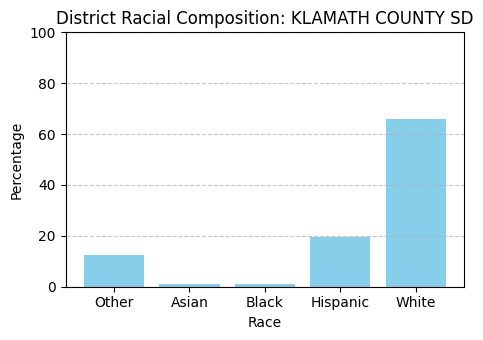


District Overview -> KLAMATH COUNTY SD (OR)

Total Students: 37852.0
Number of Schools: 23
Opportunity Estimate: 0


{'state': 'OR',
 'LEAID': '4107020',
 'dist': 'KLAMATH COUNTY SD',
 'schools': ['chiloquin elementary school',
  'ferguson elementary school',
  'gearhart elementary school',
  'henley elementary school',
  'keno elementary school',
  'malin elementary school',
  'merrill elementary school',
  'peterson elementary school',
  'shasta elementary school',
  'stearns elementary school',
  'brixner junior high school',
  'henley middle school',
  'chiloquin high school',
  'henley high school',
  'lost river high school',
  'mazama high school',
  'bonanza elementary school',
  'gilchrist elementary school',
  'bonanza junior/senior high school',
  'gilchrist junior/senior high school',
  'sage community school',
  'falcon heights academy',
  'falcon heights'],
 'district_comp': {'ENR_OTH': 4787.0,
  'ENR_AS': 350.0,
  'ENR_BL': 341.0,
  'ENR_HI': 7465.0,
  'ENR_WH': 24909.0},
 'num_students': 37852.0,
 'opp_est': 0}

In [ ]:
d.ds_ov('4107020', plot=True, pretty_print=True)

In [ ]:
or_data = data[data['LEA_STATE'] == 'OR']
or_data.head()

,COMBOKEY,LEA_STATE,LEAID,LEA_NAME,SCH_NAME,YEAR,SCH_APENR_IND,SCH_APCOURSES,ENR_AP,ENR_AP_AS,...,ENR,ENR_AS,ENR_BL,ENR_HI,ENR_WH,ENR_OTH,ENR_TEACH,APLIKELIHOOD_BL,APLIKELIHOOD_HI,APLIKELIHOOD_AS
138420,1.60261E+11,OR,1602610,PLEASANT VALLEY ELEM DIST,PLEASANT VALLEY ELEM-JR HIGH,2013,NaN,NaN,NaN,NaN,...,4.0,0.0,0.0,0.0,4.0,0.0,2.00000,NaN,NaN,NaN
407890,4.1E+11,OR,4100003,FALLS CITY SD 57,FALLS CITY ELEMENTARY SCHOOL,2011,NaN,NaN,NaN,NaN,...,111.0,2.0,0.0,7.0,100.0,2.0,NaN,NaN,NaN,NaN
407891,4.1E+11,OR,4100003,FALLS CITY SD 57,FALLS CITY ELEMENTARY SCHOOL,2013,NaN,NaN,NaN,NaN,...,170.0,0.0,2.0,10.0,151.0,7.0,28.33333,NaN,NaN,NaN
407892,4.1E+11,OR,4100003,Falls City SD 57,Falls City Elementary School,2015,NaN,NaN,NaN,NaN,...,188.0,0.0,2.0,7.0,172.0,7.0,17.09091,NaN,NaN,NaN
407893,4.1E+11,OR,4100003,Falls City SD 57,Falls City Elementary School,2017,NaN,NaN,NaN,NaN,...,130.0,0.0,0.0,9.0,111.0,10.0,10.00000,NaN,NaN,NaN


In [ ]:
np.random.seed(42)

distribution_params = {
    'ENR': {'mean': 1000, 'std': 200},
    'ENR_OTH': {'mean': 100, 'std': 20},
    'ENR_AS': {'mean': 200, 'std': 40},
    'ENR_BL': {'mean': 150, 'std': 30},
    'ENR_HI': {'mean': 100, 'std': 25},
    'ENR_HP': {'mean': 50, 'std': 15},
    'ENR_WH': {'mean': 500, 'std': 100},
    'SCH_FTETEACH_TOT': {'mean': 50, 'std': 10},
    'ENRHIGH_M': {'mean': 500, 'std': 100},
    'ENRHIGH_OTH': {'mean': 50, 'std': 10},
    'ENRHIGH_AS': {'mean': 100, 'std': 20},
    'ENRHIGH_BL': {'mean': 75, 'std': 15},
    'ENRHIGH_HI': {'mean': 40, 'std': 10},
    'ENRHIGH_WH': {'mean': 200, 'std': 50},
    'SCH_APENR_IND': {'mean': 0.3, 'std': 0.1},
    'SCH_APCOURSES': {'mean': 10, 'std': 2},
    'ENR_AP': {'mean': 100, 'std': 30},
    'ENR_AP_BL': {'mean': 15, 'std': 5},
    'ENR_AP_HI': {'mean': 30, 'std': 5},
    'ENR_AP_WH': {'mean': 50, 'std': 5},
    'ENR_AP_AS': {'mean': 10, 'std': 3},
    'ENR_AP_OTH': {'mean': 5, 'std': 1},
    'ENR_TEACH': {'mean': 20, 'std': 5},
    'APLIKELIHOOD_BL': {'mean': 0.3, 'std': 0.05},
    'APLIKELIHOOD_HI': {'mean': 0.4, 'std': 0.05},
    'APLIKELIHOOD_AS': {'mean': 0.2, 'std': 0.03}
}

for col in dummy.columns[6:]:
    mean = distribution_params[col]['mean']
    std = distribution_params[col]['std']

    dummy[col] = np.random.normal(loc=mean, scale=std, size=dummy.shape[0])


dummy = dummy.round({col: 0 for col in dummy.columns[6:]})
dummy.head()

NameError: name 'dummy' is not defined

In [ ]:
district_data = data[data['LEAID'] == '802490']

In [ ]:
district_data.head()

,COMBOKEY,LEA_STATE,LEAID,LEA_NAME,SCH_NAME,YEAR,SCH_APENR_IND,SCH_APCOURSES,ENR_AP,ENR_AP_AS,...,ENR,ENR_AS,ENR_BL,ENR_HI,ENR_WH,ENR_OTH,ENR_TEACH,APLIKELIHOOD_BL,APLIKELIHOOD_HI,APLIKELIHOOD_AS
76504,80249000099,CO,802490,BOULDER VALLEY SCHOOL DISTRICT NO. RE2,BEAR CREEK ELEMENTARY SCHOOL,2011,NaN,NaN,NaN,NaN,...,379.0,40.0,2.0,28.0,271.0,38.0,NaN,NaN,NaN,NaN
76505,80249000099,CO,802490,BOULDER VALLEY SCHOOL DISTRICT NO. RE2,BEAR CREEK ELEMENTARY SCHOOL,2013,NaN,NaN,NaN,NaN,...,419.0,31.0,4.0,16.0,322.0,46.0,17.23571,NaN,NaN,NaN
76506,80249000099,CO,802490,Boulder Valley School District No. Re2,BEAR CREEK ELEMENTARY SCHOOL,2017,NaN,NaN,NaN,NaN,...,449.0,32.0,4.0,22.0,352.0,39.0,20.17071,NaN,NaN,NaN
76507,80249000099,CO,802490,Boulder Valley School District No. Re2,Bear Creek Elementary School,2020,NaN,NaN,NaN,NaN,...,343.0,33.0,1.0,14.0,257.0,38.0,16.11842,NaN,NaN,NaN
76508,80249000099,CO,802490,Boulder Valley School District No. Re2,Bear Creek Elementary School,2021,NaN,NaN,NaN,NaN,...,347.0,25.0,3.0,17.0,261.0,41.0,17.32401,NaN,NaN,NaN


In [ ]:
district_data['ENR_AP'].describe()

,ENR_AP
count,57.000000
mean,369.298246
std,301.823444
min,4.000000
25%,42.000000
50%,419.000000
75%,562.000000
max,1045.000000


In [ ]:
or_data

,COMBOKEY,LEA_STATE,LEAID,LEA_NAME,SCH_NAME,YEAR,SCH_APENR_IND,SCH_APCOURSES,ENR_AP,ENR_AP_AS,...,ENR,ENR_AS,ENR_BL,ENR_HI,ENR_WH,ENR_OTH,ENR_TEACH,APLIKELIHOOD_BL,APLIKELIHOOD_HI,APLIKELIHOOD_AS
138420,1.60261E+11,OR,1602610,PLEASANT VALLEY ELEM DIST,PLEASANT VALLEY ELEM-JR HIGH,2013,NaN,NaN,NaN,NaN,...,4.0,0.0,0.0,0.0,4.0,0.0,2.00000,NaN,NaN,NaN
407890,4.1E+11,OR,4100003,FALLS CITY SD 57,FALLS CITY ELEMENTARY SCHOOL,2011,NaN,NaN,NaN,NaN,...,111.0,2.0,0.0,7.0,100.0,2.0,NaN,NaN,NaN,NaN
407891,4.1E+11,OR,4100003,FALLS CITY SD 57,FALLS CITY ELEMENTARY SCHOOL,2013,NaN,NaN,NaN,NaN,...,170.0,0.0,2.0,10.0,151.0,7.0,28.33333,NaN,NaN,NaN
407892,4.1E+11,OR,4100003,Falls City SD 57,Falls City Elementary School,2015,NaN,NaN,NaN,NaN,...,188.0,0.0,2.0,7.0,172.0,7.0,17.09091,NaN,NaN,NaN
407893,4.1E+11,OR,4100003,Falls City SD 57,Falls City Elementary School,2017,NaN,NaN,NaN,NaN,...,130.0,0.0,0.0,9.0,111.0,10.0,10.00000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415729,4.2E+11,OR,4199999,ODE Juvenile Detention Education Program (JDEP),KLAMATH COUNTY JUVENILE,2017,NaN,NaN,NaN,NaN,...,8.0,0.0,0.0,1.0,3.0,4.0,8.00000,NaN,NaN,NaN
415730,4.2E+11,OR,4199999,ODE JUVENILE DETENTION EDUCATION PROGRAM,COIC SKILL LAB,2011,NaN,NaN,NaN,NaN,...,15.0,0.0,0.0,2.0,13.0,0.0,NaN,NaN,NaN,NaN
415731,4.2E+11,OR,4199999,ODE JUVENILE DETENTION EDUCATION PROGRAM,COIC SKILL LAB,2013,0.0,NaN,NaN,NaN,...,14.0,0.0,4.0,2.0,8.0,0.0,14.00000,NaN,NaN,NaN
415732,4.2E+11,OR,4199999,ODE Juvenile Detention Education Program (JDEP),COIC SKILL LAB,2015,NaN,NaN,NaN,NaN,...,9.0,0.0,0.0,0.0,7.0,2.0,9.00000,NaN,NaN,NaN


 # Front-end top page – Following this page: https://projects.propublica.org/miseducation/  

The main interpretive element/equity indicator/opportunity estimate will be “School districts where White students are more likely to be in an Advanced Placement class, compared with Black (Hispanic) students in 2011-12 and 2021-22.”

We could depict this on a map just like in the above page with a heatmap for likelihood depicted on a map with tabs for Black and Hispanic students. When we click/scroll over the district, it would be nice to see the likelihood estimates shown for both those timepoints. It might also be nice to add other infographic elements like up arrow, down arrow shown for quick summary view in addition to the estimate.  

### If we can add the state-level table shown below with four columns (again inspired by the above page but with some modifications on the elements), that would be great:  

* State

* Modal number of AP Classes Offered in Schools – student weighted  

* Opportunity estimate for 2011-12

* Opportunity estimate for 2021-22  

In [ ]:
def state_overview(data):
    state_dict = {
        'state' : [],
        'ap' : [],
        'opp_est_1' : [],
        'opp_est_2' : []
    }
    data['WEIGHTED_AP'] = data['ENR_AP'] * data['ENR']

    state_df = data.groupby('LEA_STATE').agg({
        'WEIGHTED_AP': 'sum',
        'ENR': 'sum',
        'ENR_BL' : 'sum',
        'ENR_WH' : 'sum',
        'ENR_AP' : 'sum',
        'ENR_AP_BL' : 'sum',
        'ENR_AP_WH' : 'sum'    })

    state_df['WEIGHTED_MEAN_AP'] = state_df['WEIGHTED_AP'] / state_df['ENR']
    state_df = state_df[['ENR', 'ENR_WH', 'ENR_BL',  'ENR_AP', 'ENR_AP_WH', 'ENR_AP_BL', 'WEIGHTED_MEAN_AP', ]].reset_index()
    state_df['AP_RT_WH'] = state_df['ENR_AP_WH'] / state_df['ENR_WH']
    state_df['AP_RT_Bl'] = state_df['ENR_AP_BL'] / state_df['ENR_BL']
    state_df['OPPEST_WB'] = state_df['AP_RT_Bl'] /  state_df['AP_RT_WH']

    return state_df
x = state_overview(or_data)

NameError: name 'or_data' is not defined

In [ ]:
x.head()

# Overview section

* Name of school district, Number of students, teachers, and schools in 2021-22 (latest data)

* If map of the district and the listing of schools in the district on the right as a table can be added as seen above, that’s great.

* District composition as shown there will also be nice

* Then we show the opportunity estimate for that district as well at the two time points as done at the national and state levels above

In [ ]:
def dist_overview(dist_data, plot=False, pretty_print=False):
    """
    Generates a district overview with racial enrollment counts and total students.
    Optionally plots the racial composition and prints a formatted overview.

    Parameters:
        dist_data (DataFrame): Input data with school names, ENR, and race-based ENR columns.
        plot (bool): If True, displays a pie chart of district racial composition.
        pretty_print (bool): If True, prints a formatted summary table.

    Returns:
        dict: Dictionary containing school list, district composition, total students, and opportunity estimate (placeholder).
    """
    district_overview = {
        "schools": [],
        "district_comp": {
            "ENR_OTH": 0,
            "ENR_AS": 0,
            "ENR_BL": 0,
            "ENR_HI": 0,
            "ENR_WH": 0
        },
        "num_students": 0,
        "opp_est": ""
    }

    enr_race = ["ENR_OTH", "ENR_AS", "ENR_BL", "ENR_HI", "ENR_WH"]

    for index, row in dist_data.iterrows():
        school = row['SCH_NAME'].lower()
        if school not in district_overview['schools']:
            district_overview['schools'].append(school)

        for race in enr_race:
            district_overview['district_comp'][race] += row[race]

        district_overview['num_students'] += row['ENR']

    if plot:
        labels = {
            "ENR_OTH": "Other",
            "ENR_AS": "Asian",
            "ENR_BL": "Black",
            "ENR_HI": "Hispanic",
            "ENR_WH": "White"
        }
        comp = district_overview['district_comp']
        race_labels = [labels[r] for r in enr_race]
        values = [comp[r] / district_overview['num_students'] * 100 for r in enr_race]
        plt.figure(figsize=(4.84, 3.5), dpi=100)
        plt.bar(race_labels, values, color='skyblue')
        plt.title('District Racial Composition')
        plt.xlabel('Race')
        plt.ylabel('Percentage')
        plt.ylim(0, 100)  # Assuming percentages
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        plt.show()

    if pretty_print:
        print(f"\nDistrict Overview -> ({dist_data['LEA_NAME'][:1]})")
        #print(f"\nDistrict Overview -> {print(f"{school} \n") for school in district_overview['schools']}")
        #print(f"\nDistrict Overview ({dist_data['LEA_NAME']}):\n" + "\n".join(f"{school}" for school in district_overview['schools']))

        print("=================")
        comp_df = pd.DataFrame.from_dict(district_overview['district_comp'], orient='index', columns=['Student Count'])
        comp_df.index = comp_df.index.map({
            "ENR_OTH": "Other",
            "ENR_AS": "Asian",
            "ENR_BL": "Black",
            "ENR_HI": "Hispanic",
            "ENR_WH": "White"
        })
        comp_df['% of Total'] = (comp_df['Student Count'] / district_overview['num_students'] * 100).round(2)
        print(comp_df.to_string())
        print(f"\nTotal Students: {district_overview['num_students']}")
        print(f"Number of Schools: {len(district_overview['schools'])}")
        print(f"Opportunity Estimate: {district_overview['opp_est']}")

    return district_overview
test = dist_overview(district_data, plot=True, pretty_print=True)

# Fact Sheet Section
## Students

1. Percentage of non-white students

2. Percentage of economically disadvantaged students

3. Percentage of high school students taking at least 1 AP course

## Teachers and Resources

1. Student-teacher ratio

2. Modal number of AP Courses per school

In [ ]:
def fact_sheet(district_data):
    fact_dict = {
        "non_wh": 0,
        "eds": 0,
        "hs1ap": 0,
        "str": 0,
        "apsc": 0
    }

    if district_data['ENR_AP'].notna().any():
        enr_ap = float((district_data['ENR_AP'].sum() / district_data['ENR'].sum()) * 100)

    enr_nw = (sum(district_data['ENR'] - district_data['ENR_WH']) / sum(district_data['ENR']) * 100)

    fact_dict['non_wh'] = round(enr_nw, 1)
    fact_dict['str'] = round(float(district_data['ENR_TEACH'].mean()), 1)
    fact_dict['hs1ap'] = round(enr_ap, 1)

    # Plot donut charts
    labels_map = {
        "non_wh": "Non-White Enrollment",
        "hs1ap": "AP Participation",
        "str": "Student-Teacher Ratio"
    }

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))

    for ax, key in zip(axs, ['non_wh', 'hs1ap', 'str']):
        percent = fact_dict[key]
        sizes = [percent, 100 - percent]
        colors = ['#66b3ff', '#f0f0f0']

        wedges, texts = ax.pie(
            sizes,
            colors=colors,
            startangle=90,
            wedgeprops={'width': 0.4}
        )

        # Add label inside the donut hole
        ax.text(0, 0, f"{percent:.1f}%", ha='center', va='center', fontsize=12, fontweight='bold')

        ax.set_title(labels_map[key], fontsize=12)
        ax.axis('equal')  # Keep the pie circular

    plt.tight_layout()
    plt.show()
fact_sheet(district_data)